# Dual-sensor fitting and correction pipeline

This notebook adapts the single-sensor fitting pipeline for CSVs with readings from **front** (registers 10–19) and **back** (registers 0–9) sensors.

- Load a raw CSV and optionally restrict to **front**, **back**, or **both** via `SENSOR_SIDE`.
- Run the same pipeline as `fitting.ipynb`: clean, per-trial stats, regression, constant-offset correction, facet plots.
- When `SENSOR_SIDE == "both"`: plot **differential** (average front − average back per trial) and **diameter** (front + back sum per trial).


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress

STRENGTH_TOLERANCE = 2000.0
BACK_REGISTERS = range(0, 10)   # 0-9
FRONT_REGISTERS = range(10, 20) # 10-19

sns.set(style="whitegrid")
%matplotlib inline


In [50]:
# Basic loading and cleaning helpers (dual front/back)

DATA_DIR = Path("../data")

REQUIRED_COLUMNS = [
    "trial",
    "register",
    "rdistance",
    "strength",
    "edistance",
]


def load_raw_csv_dual(csv_path, sensor_side: str = "both") -> pd.DataFrame:
    """Load a raw CSV and filter by sensor side (front=regs 10-19, back=0-9).

    Parameters
    ----------
    csv_path : str or Path
        Path to the raw CSV file.
    sensor_side : str
        "front" | "back" | "both". Filter to front registers (10-19), back (0-9), or both.
    """
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df.dropna(subset=REQUIRED_COLUMNS).copy()

    # Restrict to back (0-9) and front (10-19) only; label side
    back_mask = df["register"].isin(BACK_REGISTERS)
    front_mask = df["register"].isin(FRONT_REGISTERS)
    df = df[back_mask | front_mask].copy()
    df["sensor_side"] = np.where(df["register"].isin(FRONT_REGISTERS), "front", "back")

    if sensor_side == "front":
        df = df[df["sensor_side"] == "front"].copy()
    elif sensor_side == "back":
        df = df[df["sensor_side"] == "back"].copy()
    # "both" keeps all rows with sensor_side already set

    df["error_mm"] = df["rdistance"] - df["edistance"]
    return df


def remove_outliers_per_trial(
    df: pd.DataFrame,
    value_col: str = "rdistance",
    trial_col: str = "trial",
    n_std: float = 2.0,
) -> pd.DataFrame:
    """Remove per-trial outliers based on median ± n_std * std in value_col."""
    def keep_inliers(g: pd.DataFrame) -> pd.DataFrame:
        med = g[value_col].median()
        std = g[value_col].std()
        if std == 0 or pd.isna(std):
            return g
        return g[abs(g[value_col] - med) <= n_std * std]

    return (
        df.groupby(trial_col, group_keys=False)
        .apply(keep_inliers)
        .reset_index(drop=True)
    )


def clean_data(df: pd.DataFrame, value_col: str = "rdistance", n_std: float = 2.0) -> pd.DataFrame:
    """Drop nulls, recompute error_mm, and remove per-trial outliers."""
    work = df.dropna(subset=REQUIRED_COLUMNS).copy()
    work["error_mm"] = work["rdistance"] - work["edistance"]
    cleaned = remove_outliers_per_trial(work, value_col=value_col, trial_col="trial", n_std=n_std)
    return cleaned


def get_trial_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-trial stats (expected_distance, median/mean distance, errors, count, strength)."""
    work = df.copy()
    if "error_mm" not in work.columns:
        work["error_mm"] = work["rdistance"] - work["edistance"]
    work["abs_strength"] = work["strength"].abs()
    stats = (
        work.groupby("trial")
        .agg(
            expected_distance=("edistance", "median"),
            median_distance=("rdistance", "median"),
            mean_distance=("rdistance", "mean"),
            std_distance=("rdistance", "std"),
            median_error=("error_mm", "median"),
            mean_error=("error_mm", "mean"),
            count=("rdistance", "size"),
            mean_strength=("abs_strength", "mean"),
            median_strength=("abs_strength", "median"),
        )
        .reset_index()
    )
    return stats


def strength_rejection(
    df: pd.DataFrame,
    strength_col: str = "strength",
    strength_center: float | None = None,
    strength_tol: float = STRENGTH_TOLERANCE,
    use_abs: bool = True,
) -> tuple[pd.DataFrame, float]:
    """Reject measurements whose strength is far from the probable object strength."""
    work = df.copy()
    s = work[strength_col].abs() if use_abs else work[strength_col]
    if strength_center is None:
        strength_center = float(s.median())
    lower = strength_center - strength_tol
    upper = strength_center + strength_tol
    if use_abs:
        mask = (s >= lower) & (s <= upper)
    else:
        mask = (work[strength_col] >= lower) & (work[strength_col] <= upper)
    filtered = work[mask].reset_index(drop=True)
    return filtered, strength_center

In [51]:
# Plotting and regression helpers

def plot_expected_vs_actual(
    stats: pd.DataFrame,
    use_mean: bool = False,
    title: str | None = None,
    ax=None,
):
    """Scatter of per-trial stats vs trial index with best-fit line."""
    y_col = "mean_distance" if use_mean else "median_distance"
    stats = stats.dropna(subset=["expected_distance", y_col]).copy()
    if stats.empty:
        raise ValueError("No valid rows after dropping NaNs for expected_distance / actual distance")

    x = stats["trial"].values
    y = stats[y_col].values

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    ax.scatter(x, y, label="data")
    x_line = np.linspace(x.min(), x.max(), 200)
    if len(x) >= 2:
        slope, intercept, r, p, se = linregress(x, y)
        ax.plot(x_line, slope * x_line + intercept, "r-", label=f"fit (R²={r**2:.3f})")
        ax.text(0.05, 0.95, f"y = {slope:.4f} x + {intercept:.2f}", transform=ax.transAxes, va="top", ha="left")

    ax.set_xlabel("trial")
    ax.set_ylabel(f"{y_col} (mm)")
    ax.set_title(title or "Per-trial distance vs trial")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return ax


def plot_error_summaries(stats: pd.DataFrame, use_mean: bool = False):
    """Graphical representations of per-trial error vs trial and error histogram."""
    err_col = "mean_error" if use_mean else "median_error"
    stats = stats.dropna(subset=["expected_distance", err_col]).copy()
    if stats.empty:
        raise ValueError("No valid rows after dropping NaNs for expected_distance / error")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.scatterplot(data=stats, x="trial", y=err_col, ax=axes[0])
    axes[0].axhline(0, color="k", linestyle="--", alpha=0.7)
    axes[0].set_xlabel("trial")
    axes[0].set_ylabel(f"{err_col} (mm)")
    axes[0].set_title("Error vs trial")
    sns.histplot(stats[err_col], bins=30, kde=True, ax=axes[1])
    axes[1].axvline(0, color="k", linestyle="--", alpha=0.7)
    axes[1].set_xlabel(f"{err_col} (mm)")
    axes[1].set_title("Error distribution")
    plt.tight_layout()
    return axes


def fit_linear_model(stats: pd.DataFrame, use_mean: bool = False) -> dict | None:
    """Fit line of best fit y = slope * x + intercept. Returns dict with slope, intercept, R^2, etc."""
    y_col = "mean_distance" if use_mean else "median_distance"
    s = stats.dropna(subset=["expected_distance", y_col])
    if len(s) < 2:
        return None
    slope, intercept, r, p, se = linregress(s["expected_distance"], s[y_col])
    return {
        "slope": float(slope),
        "intercept": float(intercept),
        "r_squared": float(r**2),
        "p_value": float(p),
        "std_err": float(se),
    }


def plot_regression_residuals(stats: pd.DataFrame, fit: dict, use_mean: bool = False):
    """Plot residuals of the regression line (scatter vs trial + histogram)."""
    if fit is None:
        raise ValueError("fit is None; run fit_linear_model first")
    y_col = "mean_distance" if use_mean else "median_distance"
    s = stats.dropna(subset=["expected_distance", y_col]).copy()
    x = s["trial"].values
    y = s[y_col].values
    # Predictions still based on expected_distance, since fit was done in that space
    y_pred = fit["slope"] * s["expected_distance"].values + fit["intercept"]
    resid = y - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(x, resid)
    axes[0].axhline(0, color="k", linestyle="--", alpha=0.7)
    axes[0].set_xlabel("trial")
    axes[0].set_ylabel("residual (mm)")
    axes[0].set_title("Residuals vs trial")
    axes[0].grid(True, alpha=0.3)
    sns.histplot(resid, bins=30, kde=True, ax=axes[1])
    axes[1].axvline(0, color="k", linestyle="--", alpha=0.7)
    axes[1].set_xlabel("residual (mm)")
    axes[1].set_title("Residual distribution")
    plt.tight_layout()
    return axes

In [52]:
def fit_constant_offset_expected_minus_actual(
    df: pd.DataFrame,
    expected_col: str = "edistance",
    actual_col: str = "rdistance",
) -> dict:
    """Fit constant offset minimizing sum((expected - (actual + c))^2). Returns offset_mm to add to actual."""
    work = df.dropna(subset=[expected_col, actual_col]).copy()
    if work.empty:
        raise ValueError("No valid rows after dropping NaNs for expected/actual columns")
    err = work[expected_col] - work[actual_col]
    offset = err.mean()
    err_std = err.std()
    return {"offset_mm": float(offset), "offset_std_mm": float(err_std), "n_samples": int(err.shape[0])}


def apply_constant_offset_to_actual(
    df: pd.DataFrame,
    offset_mm: float,
    actual_col: str = "rdistance",
    expected_col: str = "edistance",
    out_col: str = "rdistance_offset",
) -> pd.DataFrame:
    """Apply constant offset to actual: out_col = actual + offset_mm; add error_offset_mm if expected_col present."""
    work = df.copy()
    work[out_col] = work[actual_col] + offset_mm
    if expected_col in work.columns:
        work["error_offset_mm"] = work[expected_col] - work[out_col]
    return work

In [53]:
# Constant-offset correction model with quantization bin

def fit_constant_offset(df_clean: pd.DataFrame, bin_size_mm: float = 2.5) -> dict:
    """Fit constant offset using mean error (measured ≈ true + offset + quantization_error)."""
    if "error_mm" not in df_clean.columns:
        df_clean = df_clean.copy()
        df_clean["error_mm"] = df_clean["rdistance"] - df_clean["edistance"]
    err = df_clean["error_mm"].dropna()
    offset = err.mean()
    err_std = err.std()
    return {"offset_mm": float(offset), "offset_std_mm": float(err_std), "bin_size_mm": float(bin_size_mm), "n_samples": int(err.shape[0])}


def apply_offset_correction(df_clean: pd.DataFrame, offset_mm: float) -> pd.DataFrame:
    """Apply constant offset correction to rdistance and recompute errors."""
    corrected = df_clean.copy()
    corrected["rdistance_corrected"] = corrected["rdistance"] - offset_mm
    corrected["error_corrected_mm"] = corrected["rdistance_corrected"] - corrected["edistance"]
    return corrected


def fit_slope_one_offset(stats: pd.DataFrame, use_mean: bool = False) -> dict | None:
    """Fit best constant offset for slope-1 line (y = x + b). Uses per-trial stats."""
    y_col = "mean_distance" if use_mean else "median_distance"
    s = stats.dropna(subset=["expected_distance", y_col])
    if len(s) < 2:
        return None
    x, y = s["expected_distance"].values, s[y_col].values
    offset = float((y - x).mean())
    residuals = y - (x + offset)
    return {"offset_mm": offset, "mean_error_mm": float(residuals.mean()), "mean_abs_error_mm": float(abs(residuals).mean()), "std_error_mm": float(residuals.std()), "n_points": int(len(s))}


def plot_corrected_vs_expected(df_corrected: pd.DataFrame, bin_size_mm: float = 2.5, aggregate: bool = True):
    """Plot corrected distances vs trial with ±bin_size_mm band in y (distance)."""
    if aggregate:
        work = df_corrected.copy()
        if "rdistance_corrected" not in work.columns:
            raise ValueError("expected 'rdistance_corrected' in df_corrected")
        stats = work.groupby("trial").agg(expected_distance=("edistance", "median"), median_corrected=("rdistance_corrected", "median")).reset_index()
        x, y = stats["trial"].values, stats["median_corrected"].values
    else:
        x, y = df_corrected["trial"].values, df_corrected["rdistance_corrected"].values
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(x, y, label="corrected data", alpha=0.8)
    x_line = np.linspace(x.min(), x.max(), 200)
    # Reference band around mean corrected distance
    y_mean = y.mean()
    ax.plot(x_line, np.full_like(x_line, y_mean), "k--", label="mean corrected")
    ax.plot(x_line, y_mean + bin_size_mm, "r:", label=f"mean ± {bin_size_mm:.1f} mm")
    ax.plot(x_line, y_mean - bin_size_mm, "r:")
    ax.set_xlabel("trial")
    ax.set_ylabel("corrected distance (mm)")
    ax.set_title("Corrected distance vs trial with bin band")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return ax


def plot_expected_and_corrected_facet_wrap(stats: pd.DataFrame, df_corrected: pd.DataFrame, bin_size_mm: float = 2.5, use_mean: bool = False, aggregate_corrected: bool = True, height: float = 4.5):
    """Facet-wrap: expected vs actual, and corrected vs expected (±bin band)."""
    y_col = "mean_distance" if use_mean else "median_distance"
    s = stats.dropna(subset=["expected_distance", y_col]).copy()
    if s.empty:
        raise ValueError("No valid rows in stats for expected_distance / actual distance")
    df_expected = s[["expected_distance", y_col]].rename(columns={y_col: "y"})
    df_expected["panel"] = "Expected vs Actual with Linear Fit"
    if aggregate_corrected:
        work = df_corrected.copy()
        if "rdistance_corrected" not in work.columns:
            raise ValueError("expected 'rdistance_corrected' in df_corrected")
        corr_stats = work.groupby("trial").agg(expected_distance=("edistance", "median"), y=("rdistance_corrected", "median")).reset_index(drop=True)
    else:
        if "rdistance_corrected" not in df_corrected.columns:
            raise ValueError("expected 'rdistance_corrected' in df_corrected")
        corr_stats = df_corrected[["edistance", "rdistance_corrected"]].rename(columns={"edistance": "expected_distance", "rdistance_corrected": "y"})
    corr_stats = corr_stats.dropna(subset=["expected_distance", "y"]).copy()
    corr_stats["panel"] = "Constant Offset Corrected vs Expected (bin band)"
    df_long = pd.concat([df_expected, corr_stats], ignore_index=True)
    g = sns.FacetGrid(df_long, col="panel", col_wrap=2, sharex=False, sharey=False, height=height, aspect=1.1)
    g.map_dataframe(sns.scatterplot, x="expected_distance", y="y", alpha=0.85)
    for ax, panel in zip(g.axes.flat, g.col_names):
        sub = df_long[df_long["panel"] == panel]
        x = sub["expected_distance"].to_numpy()
        y = sub["y"].to_numpy()
        x_line = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_line, x_line, "k--", label="y = x")
        if panel == "Expected vs Actual with Linear Fit":
            if len(x) >= 2:
                slope, intercept, r, p, se = linregress(x, y)
                ax.plot(x_line, slope * x_line + intercept, "r-", label=f"fit (R²={r**2:.3f})")
            ax.set_ylabel(f"{y_col} (mm)")
        else:
            ax.plot(x_line, x_line + bin_size_mm, "r:", label=f"y = x ± {bin_size_mm:.1f} mm")
            ax.plot(x_line, x_line - bin_size_mm, "r:")
            ax.set_ylabel("Corrected Distance (mm)")
        ax.set_xlabel("Expected Distance (mm)")
        ax.grid(True, alpha=0.3)
        ax.legend()
    g.set_titles(col_template="{col_name}")
    plt.tight_layout()
    return g


def summarize_corrected_errors(df_corrected: pd.DataFrame) -> dict:
    """Summarize corrected errors and fraction within ±2.5 mm."""
    if "error_corrected_mm" not in df_corrected.columns:
        raise ValueError("expected 'error_corrected_mm' in df_corrected")
    err = df_corrected["error_corrected_mm"].dropna()
    return {"mean_error_mm": float(err.mean()), "std_error_mm": float(err.std()), "median_error_mm": float(err.median()), "p_within_2p5mm": float((err.abs() <= 2.5).mean()), "n": int(err.shape[0])}

In [54]:
# Dual-sensor plots: differential (front - back) and diameter (front + back) per trial

def build_dual_stats(stats_front: pd.DataFrame, stats_back: pd.DataFrame, use_mean: bool = False) -> pd.DataFrame:
    """Merge per-trial front and back stats; keep trials with both. Add diff_front_back and sum_front_back."""
    dist_col = "mean_distance" if use_mean else "median_distance"
    f = stats_front[["trial", "expected_distance", dist_col]].rename(columns={dist_col: "mean_front"})
    b = stats_back[["trial", dist_col]].rename(columns={dist_col: "mean_back"})
    dual = f.merge(b, on="trial", how="inner")
    dual["diff_front_back"] = dual["mean_front"] - dual["mean_back"]
    dual["sum_front_back"] = dual["mean_front"] + dual["mean_back"]
    return dual


def plot_differential_front_back(dual_stats: pd.DataFrame, x_expected: bool = True):
    """Plot front − back average distance by trial. X-axis: trial number (0, 1, 2, ...). Fit line of slope -5 (y = -5*x + b)."""
    fig, ax = plt.subplots(figsize=(7, 4))
    x = dual_stats["trial"].values
    y = dual_stats["diff_front_back"].values
    ax.scatter(x, y, alpha=0.8, label="data")
    ax.axhline(0, color="k", linestyle="--", alpha=0.7)
    # Fit line of slope -5: y = -5*x + b  =>  b = mean(y + 5*x)
    if len(x) >= 1:
        b = float((y + 5 * x).mean())
        x_line = np.linspace(x.min(), x.max(), 200)
        ax.plot(x_line, -5 * x_line + b, "r-", label=f"fit slope=-5 (b={b:.2f} mm)")
    ax.set_xlim(left=0)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Front − Back (mm)")
    ax.set_title("Front − Back average distance by trial")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return ax


def plot_diameter_sum_front_back(dual_stats: pd.DataFrame, x_expected: bool = True):
    """Plot front + back (diameter) by trial."""
    fig, ax = plt.subplots(figsize=(7, 4))
    x = dual_stats["trial"].values
    ax.scatter(x, dual_stats["sum_front_back"], alpha=0.8)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Front + Back (mm)")
    ax.set_title("Front + Back (diameter) by trial")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return ax

In [55]:
# Pipeline config: set CSV and sensor side (front | back | both)

CSV_PATH = Path("../data/profile_dual_greenpvc_30-110-5mm_s20mm_profile2_snr35000_CFAR.csv")  # change to your dual-sensor CSV
SENSOR_SIDE = "both"  # "front" | "back" | "both"
BIN_SIZE_MM = 2.5
N_STD = 2.0
USE_MEAN = False
strength_tol = 2000.0
# Drop rows where |rdistance - edistance| > this (mm). Use -1 to disable (no drops).
EXPECTED_DISTANCE_TOLERANCE_MM = -1

Loaded 350 rows (sensor_side=both)
After cleaning: front 136 rows, back 171 rows


/var/folders/cc/tndmz9tn2p55g6c3x9hx25bc0000gn/T/ipykernel_73756/2029519607.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(keep_inliers)
/var/folders/cc/tndmz9tn2p55g6c3x9hx25bc0000gn/T/ipykernel_73756/2029519607.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(keep_inliers)


,trial,expected_distance,median_distance,mean_distance,std_distance,median_error,mean_error,count,mean_strength,median_strength
0,0,95.0,74.0,74.0,0.0,-21.0,-21.0,24,17562.333333,17549.5
1,1,93.0,61.0,61.0,0.0,-32.0,-32.0,16,19471.625000,19470.0
2,2,91.0,54.0,54.0,0.0,-37.0,-37.0,16,19761.250000,19748.0
3,3,89.0,49.0,49.0,0.0,-40.0,-40.0,21,21634.142857,21638.0
4,4,87.0,45.0,45.0,0.0,-42.0,-42.0,20,21893.200000,21895.5


,trial,expected_distance,median_distance,mean_distance,std_distance,median_error,mean_error,count,mean_strength,median_strength
0,0,95.0,67.0,67.0,0.0,-28.0,-28.0,22,2771.500000,2766.5
1,1,93.0,75.0,75.0,0.0,-18.0,-18.0,25,1733.920000,1732.0
2,2,91.0,78.0,78.0,0.0,-13.0,-13.0,25,2514.640000,2515.0
3,3,89.0,82.0,82.0,0.0,-7.0,-7.0,20,1439.950000,1439.0
4,4,87.0,88.0,88.0,0.0,1.0,1.0,23,814.956522,819.0


[front] Linear regression fit: {'slope': 2.928571428571428, 'intercept': -209.35714285714283, 'r_squared': 0.9441168211176633, 'p_value': 0.00025583028750647335, 'std_err': 0.3186386860456504}


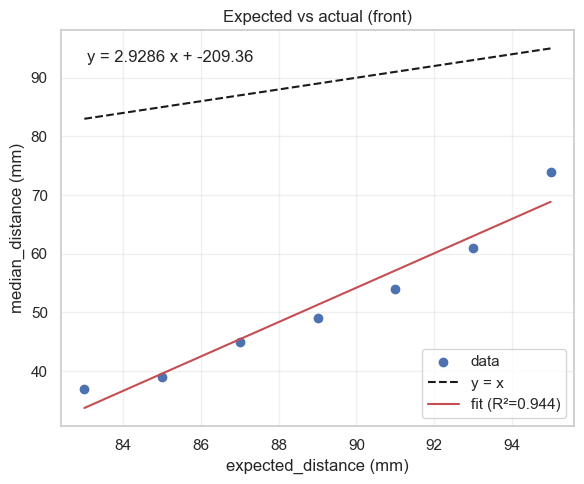

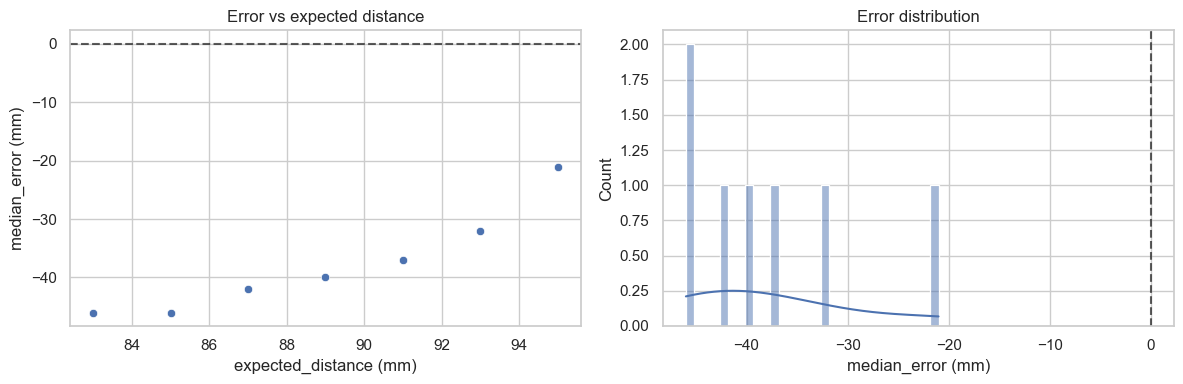

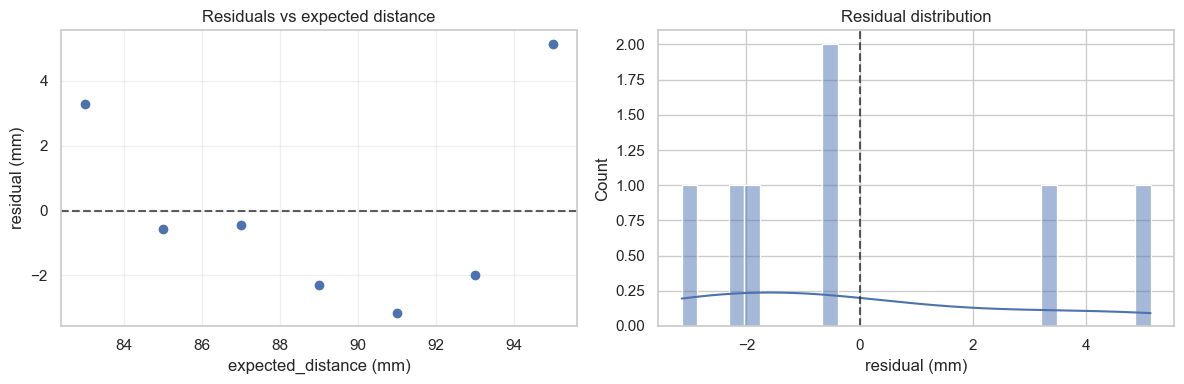

[front] Strength rejection: center≈21639.5, kept 95/136 rows
[front] Offset model: {'offset_mm': -37.338235294117645, 'offset_std_mm': 8.753598699739348, 'bin_size_mm': 2.5, 'n_samples': 136}
[front] Corrected error summary: {'mean_error_mm': 5.015595781836002e-15, 'std_error_mm': 8.753598699739353, 'median_error_mm': -2.661764705882348, 'p_within_2p5mm': 0.11764705882352941, 'n': 136}


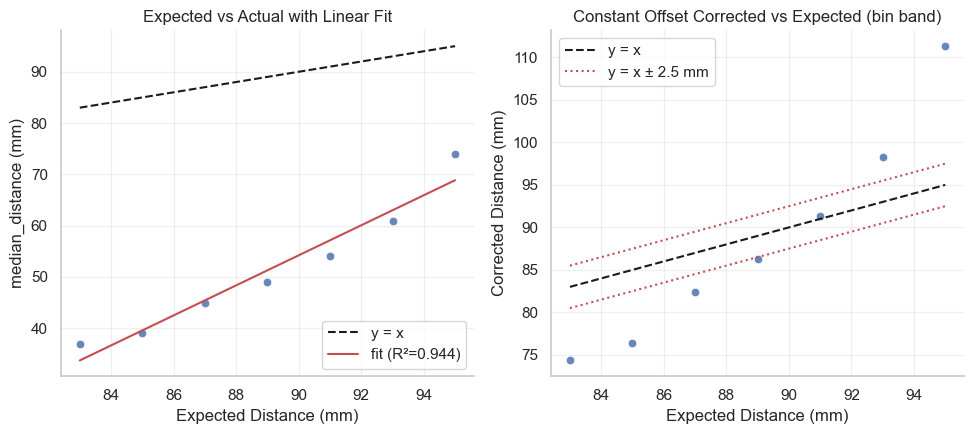

[back] Linear regression fit: {'slope': -2.482142857142857, 'intercept': 303.9107142857143, 'r_squared': 0.9914306239737277, 'p_value': 2.3151846745206178e-06, 'std_err': 0.1032013091199974}


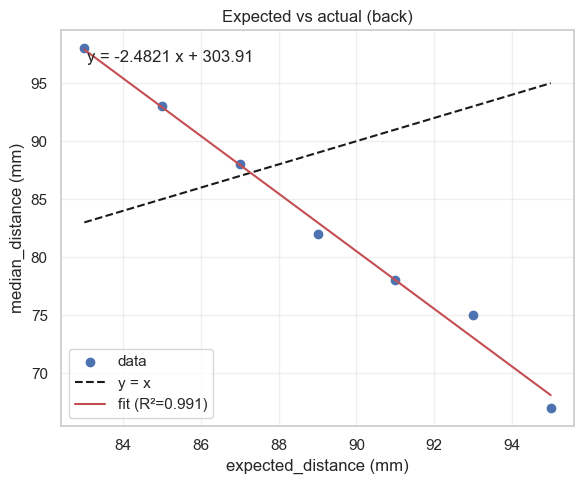

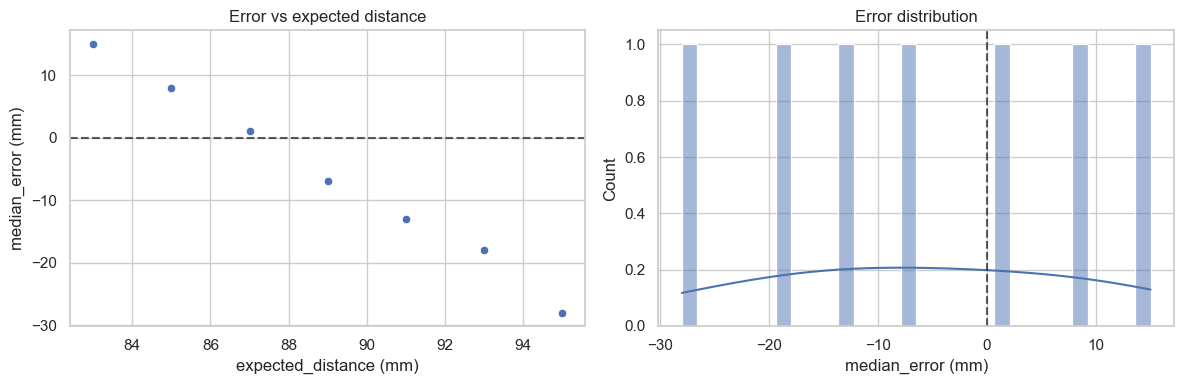

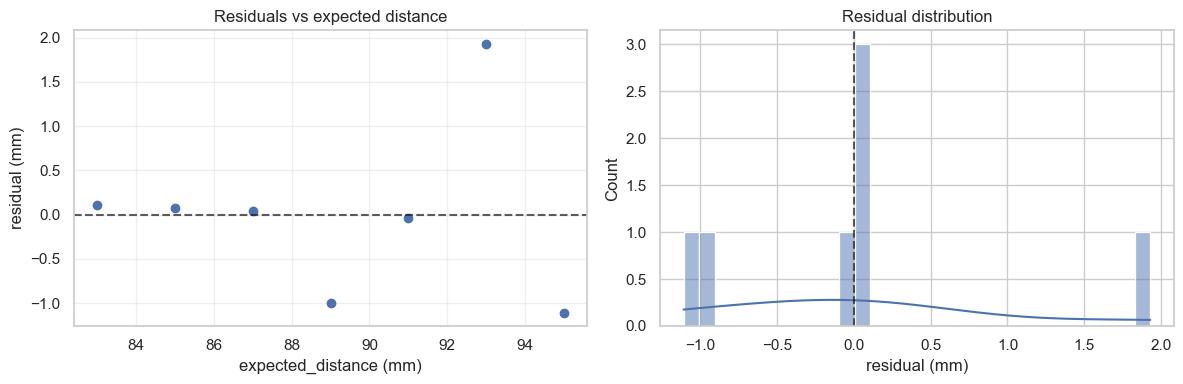

[back] Strength rejection: center≈1428.0, kept 171/171 rows
[back] Offset model: {'offset_mm': -4.9298245614035086, 'offset_std_mm': 14.347608510446607, 'bin_size_mm': 2.5, 'n_samples': 171}
[back] Corrected error summary: {'mean_error_mm': -2.659341233254176e-15, 'std_error_mm': 14.347608510446612, 'median_error_mm': -2.0701754385964932, 'p_within_2p5mm': 0.11695906432748537, 'n': 171}


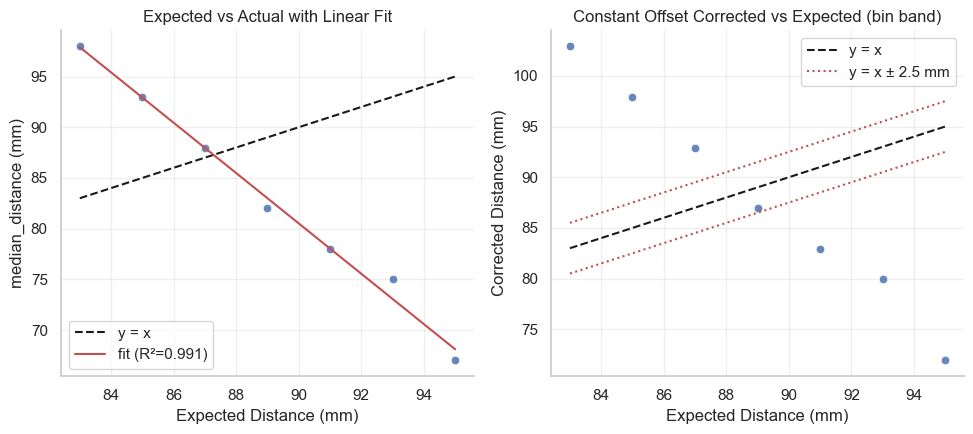

Dual stats: 7 trials with both front and back


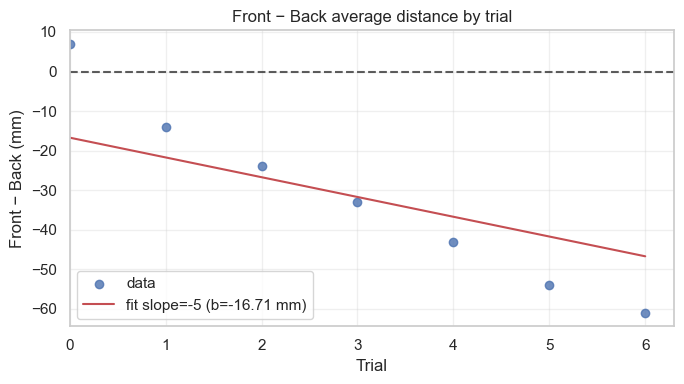

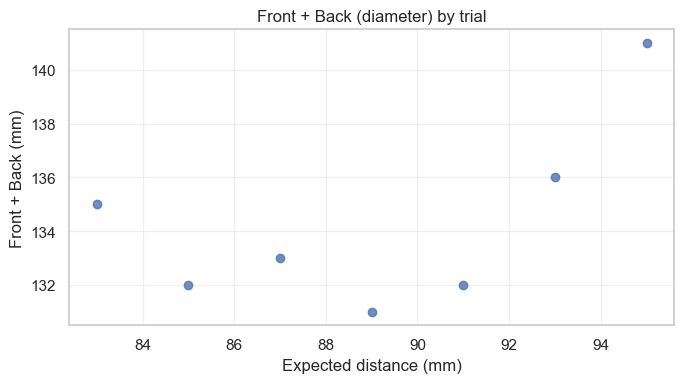

In [56]:
# Load and run pipeline (single side or both with differential/sum plots)

raw = load_raw_csv_dual(CSV_PATH, sensor_side=SENSOR_SIDE)
print(f"Loaded {len(raw)} rows (sensor_side={SENSOR_SIDE})")

if SENSOR_SIDE in ("front", "back"):
    clean = clean_data(raw, value_col="rdistance", n_std=N_STD)
    if EXPECTED_DISTANCE_TOLERANCE_MM >= 0:
        clean = clean[clean["error_mm"].abs() <= EXPECTED_DISTANCE_TOLERANCE_MM].copy()
    print(f"After cleaning: {len(clean)} rows")
    stats = get_trial_stats(clean)
    display(stats.head())
    fit = fit_linear_model(stats, use_mean=USE_MEAN)
    print("Linear regression fit:", fit)
    plot_expected_vs_actual(stats, use_mean=USE_MEAN, title=f"Expected vs actual ({SENSOR_SIDE})")
    plt.show()
    plot_error_summaries(stats, use_mean=USE_MEAN)
    plt.show()
    plot_regression_residuals(stats, fit, use_mean=USE_MEAN)
    plt.show()
    clean_sr, strength_center = strength_rejection(clean, strength_col="strength")
    print(f"Strength rejection: center≈{strength_center:.1f}, tol={strength_tol:.1f}, kept {len(clean_sr)}/{len(clean)} rows")
    stats_sr = get_trial_stats(clean_sr)
    plot_expected_vs_actual(stats_sr, use_mean=USE_MEAN, title=f"Expected vs actual ({SENSOR_SIDE}, strength-rejected)")
    plt.show()
    offset_model = fit_constant_offset(clean, bin_size_mm=BIN_SIZE_MM)
    print("Offset model:", offset_model)
    corrected = apply_offset_correction(clean, offset_model["offset_mm"])
    print("Corrected error summary:", summarize_corrected_errors(corrected))
    corrected_sr = apply_offset_correction(clean_sr, offset_model["offset_mm"])
    print("Corrected (strength-rejected) summary:", summarize_corrected_errors(corrected_sr))
    plot_expected_and_corrected_facet_wrap(stats, corrected, bin_size_mm=BIN_SIZE_MM, use_mean=USE_MEAN, aggregate_corrected=True)
    plt.show()
    plot_corrected_vs_expected(corrected_sr, bin_size_mm=BIN_SIZE_MM, aggregate=True)
    plt.show()

else:
    # SENSOR_SIDE == "both": run pipeline for front and back, then differential and sum plots
    raw_front = raw[raw["sensor_side"] == "front"].copy()
    raw_back = raw[raw["sensor_side"] == "back"].copy()
    clean_front = clean_data(raw_front, value_col="rdistance", n_std=N_STD)
    clean_back = clean_data(raw_back, value_col="rdistance", n_std=N_STD)
    if EXPECTED_DISTANCE_TOLERANCE_MM >= 0:
        clean_front = clean_front[clean_front["error_mm"].abs() <= EXPECTED_DISTANCE_TOLERANCE_MM].copy()
        clean_back = clean_back[clean_back["error_mm"].abs() <= EXPECTED_DISTANCE_TOLERANCE_MM].copy()
    print(f"After cleaning: front {len(clean_front)} rows, back {len(clean_back)} rows")

    stats_front = get_trial_stats(clean_front)
    stats_back = get_trial_stats(clean_back)
    display(stats_front.head())
    display(stats_back.head())

    for side, clean_side, stats_side in [("front", clean_front, stats_front), ("back", clean_back, stats_back)]:
        fit = fit_linear_model(stats_side, use_mean=USE_MEAN)
        print(f"[{side}] Linear regression fit:", fit)
        plot_expected_vs_actual(stats_side, use_mean=USE_MEAN, title=f"Expected vs actual ({side})")
        plt.show()
        plot_error_summaries(stats_side, use_mean=USE_MEAN)
        plt.show()
        if fit:
            plot_regression_residuals(stats_side, fit, use_mean=USE_MEAN)
            plt.show()
        clean_sr, sc = strength_rejection(clean_side, strength_col="strength")
        print(f"[{side}] Strength rejection: center≈{sc:.1f}, kept {len(clean_sr)}/{len(clean_side)} rows")
        offset_model = fit_constant_offset(clean_side, bin_size_mm=BIN_SIZE_MM)
        print(f"[{side}] Offset model:", offset_model)
        corrected_side = apply_offset_correction(clean_side, offset_model["offset_mm"])
        print(f"[{side}] Corrected error summary:", summarize_corrected_errors(corrected_side))
        plot_expected_and_corrected_facet_wrap(stats_side, corrected_side, bin_size_mm=BIN_SIZE_MM, use_mean=USE_MEAN, aggregate_corrected=True)
        plt.show()

    dual_stats = build_dual_stats(stats_front, stats_back, use_mean=USE_MEAN)
    print(f"Dual stats: {len(dual_stats)} trials with both front and back")
    plot_differential_front_back(dual_stats, x_expected=True)
    plt.show()
    plot_diameter_sum_front_back(dual_stats, x_expected=True)
    plt.show()

In [57]:
# Optional: least-squares constant offset (expected - actual) and corrected summary

if SENSOR_SIDE in ("front", "back"):
    ls_model = fit_constant_offset_expected_minus_actual(clean, expected_col="edistance", actual_col="rdistance")
    print("Least-squares offset model (expected - actual):", ls_model)
    corrected_ls = apply_constant_offset_to_actual(clean, offset_mm=ls_model["offset_mm"], actual_col="rdistance", expected_col="edistance", out_col="rdistance_ls_corrected")
    if "error_offset_mm" in corrected_ls.columns:
        e = corrected_ls["error_offset_mm"]
        print("LS corrected summary:", {"mean_error_mm": float(e.mean()), "std_error_mm": float(e.std()), "rmse_mm": float(np.sqrt((e**2).mean()))})
else:
    for side, clean_side in [("front", clean_front), ("back", clean_back)]:
        ls_model = fit_constant_offset_expected_minus_actual(clean_side, expected_col="edistance", actual_col="rdistance")
        print(f"[{side}] Least-squares offset model:", ls_model)
        corrected_ls = apply_constant_offset_to_actual(clean_side, offset_mm=ls_model["offset_mm"], actual_col="rdistance", expected_col="edistance", out_col="rdistance_ls_corrected")
        if "error_offset_mm" in corrected_ls.columns:
            e = corrected_ls["error_offset_mm"]
            print(f"[{side}] LS corrected summary:", {"mean_error_mm": float(e.mean()), "std_error_mm": float(e.std()), "rmse_mm": float(np.sqrt((e**2).mean()))})

[front] Least-squares offset model: {'offset_mm': 37.338235294117645, 'offset_std_mm': 8.753598699739348, 'n_samples': 136}
[front] LS corrected summary: {'mean_error_mm': -5.015595781836002e-15, 'std_error_mm': 8.753598699739353, 'rmse_mm': 8.72135697435029}
[back] Least-squares offset model: {'offset_mm': 4.9298245614035086, 'offset_std_mm': 14.347608510446607, 'n_samples': 171}
[back] LS corrected summary: {'mean_error_mm': 2.659341233254176e-15, 'std_error_mm': 14.347608510446612, 'rmse_mm': 14.305594925344828}
